In [1]:
# --- 메인 실행부 ---
from pymatgen.io.vasp import Vasprun

v_pure = Vasprun("vasprun_TiO2.xml", parse_dos=True, parse_eigen=True)
v_doped = Vasprun("vasprun_PTiO2.xml", parse_dos=True, parse_eigen=True)

/home/sowon-laptop/anaconda3/envs/vscode/lib/python3.12/site-packages/pymatgen/io/vasp/outputs.py:1327: UserWarning: No POTCAR file with matching TITEL fields was found in

  if potcar := self.get_potcars(path):
/home/sowon-laptop/anaconda3/envs/vscode/lib/python3.12/site-packages/pymatgen/io/vasp/outputs.py:1338: UserWarning: No POTCAR file with matching TITEL fields was found in

  potcar = self.get_potcars(path)


In [ ]:
# --- 함수 정의 ---
import numpy as np
from pymatgen.electronic_structure.core import Orbital, Spin
def get_d_orbital_dbc(vasprun_obj):
    cdos = vasprun_obj.complete_dos
    structure = vasprun_obj.final_structure
    energies = cdos.energies
    efermi = cdos.efermi

    d_indices = [i for i, site in enumerate(structure) 
                 if site.specie.symbol in ["P", "Ti", "O2"]]
    
    d_orb = [Orbital.dxy, Orbital.dyz, Orbital.dxz, Orbital.dz2, Orbital.dx2]
    
    d_sum = np.zeros_like(energies)

    for idx in d_indices:
        site = structure[idx]
        site_orb_dos = cdos.pdos[site]
        
        for orb in d_orb:
            if orb in site_orb_dos:
                d_sum += site_orb_dos[orb].get(Spin.up, 0)
                d_sum += site_orb_dos[orb].get(Spin.down, 0)
    
    # d-band center 계산
    numerator = np.trapezoid(energies * d_sum, x=energies)
    denominator = np.trapezoid(d_sum, x=energies)
    dbc = numerator / denominator if denominator != 0 else np.nan

    print(efermi)
    print(dbc)

    return {
        'num_atoms': len(d_indices),
        'energies': energies,
        'd_sum' : d_sum,
        'dbc': dbc, 
        'efermi': efermi
    }

In [4]:
# --- plotting 함수 정의 ---
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

def plot_dos_panel_absolute(ax, data, color, title):
    energies = data['energies'] - data['efermi']
    pdos = data['d_sum']
    dbc = data['dbc']
    efermi = data['efermi']

    # DOS 그리기
    ax.plot(energies, pdos, color=color, linewidth=1.5)
    ax.fill_between(energies, 0, pdos, color=color, alpha=0.3)
    
    # 3. Fermi Level을 절대 에너지 위치에 점선으로 표시
    ax.axvline(x=efermi, color='gray', linestyle=':', linewidth=1.2, label='$E_f$')
    ax.text(efermi + 0.1, np.max(pdos)*0.95, '$E_f$', color='gray', fontsize=10)
    
    # 4. d-band center 표시 (1점 쇄선)
    ax.axvline(x=dbc, color='black', linestyle='-.', linewidth=1.5)
    ax.text(dbc + 0.1, np.max(pdos)*0.85, f'{dbc:.2f} eV', color='black', fontsize=11, fontweight='bold')
    
    # 스타일링 (절대 에너지이므로 범위를 자동 조절하거나 시스템에 맞춰 설정)
    ax.set_title(title, fontsize=14, color=color, fontweight='bold')
    ax.set_xlim(efermi - 8, efermi + 4) # Fermi level 주변으로 범위 자동 설정
    ax.set_ylim(bottom=0)
    ax.set_xlabel('Energy (eV)', fontsize=12)
    ax.set_ylabel('Density of states', fontsize=12)
    ax.grid(axis='x', linestyle='--', alpha=0.4)


# data_lno = get_d_orbital_dbc(v_lno)  
# data_lnfo = get_d_orbital_dbc(v_lnfo)

# fig = plt.figure(figsize=(12, 6))
# gs = GridSpec(1, 2, wspace=0.3)

# # LNO 패널
# ax1 = fig.add_subplot(gs[0, 0])
# plot_dos_panel_absolute(ax1, data_lno, 'purple', 'LiNiO₂')

# # LNFO 패널
# ax2 = fig.add_subplot(gs[0, 1])
# plot_dos_panel_absolute(ax2, data_lnfo, 'red', 'LiNi$_{0.6}$Fe$_{0.4}$O₂')

# plt.tight_layout()
# plt.show()

In [5]:
# # ---plotting 함수 정의 수정 ---
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.gridspec import GridSpec
# from scipy.ndimage import gaussian_filter # 선을 부드럽게 만들기 위해 추가

# def plot_dos_panel_vertical(ax, data, color, title, show_ylabel=True, smoothing_sigma=2):
#     """
#     (수정됨) 가로 세로 축을 바꾸고, DOS 선을 부드럽게 만듭니다.
#     """
#     energies_raw = data['energies'] - data['efermi']
#     pdos_raw = data['d_sum'] - data['efermi']
#     dbc = data['dbc'] - data['efermi']
#     efermi = 0

#     # --- [Smoothing 적용] ---
#     # gaussian_filter를 사용하여 spiky한 데이터를 부드럽게 만듭니다.
#     # smoothing_sigma 값이 클수록 더 부드러워집니다.
#     pdos_smoothed = gaussian_filter(pdos_raw, sigma=smoothing_sigma)
#     energies = energies_raw # 에너지 축은 원본 유지

#     # --- [가로-세로 축 바꾸기] ---
#     # X축: DOS, Y축: Energy
#     # linewidth를 2 정도로 주어 더 선명하게 만듭니다.
#     ax.plot(pdos_smoothed, energies, color=color, linewidth=2.0, zorder=3)
    
#     # fill_betweenx를 사용하여 Y축(Energy) 기준으로 면적을 채웁니다.
#     occupied_mask = energies <= 0
#     ax.fill_betweenx(energies, 0, pdos_smoothed, 
#                      where=occupied_mask, 
#                      color=color, alpha=0.3, zorder=2)
#     # --- [선 및 텍스트 위치 수정 (가로 orientation)] ---
#     # 3. Fermi Level을 절대 에너지 위치에 회색 가로 점선으로 표시
#     ax.axhline(y=efermi, color='black', linestyle=':', linewidth=1.5, zorder=1)
    
#     # 4. d-band center 표시 (검은색 가로 1점 쇄선)
#     # 이미지처럼 선이 DOS 영역을 가로지르도록 설정
#     ax.axhline(y=dbc, color='black', linestyle='-.', linewidth=1.8, zorder=4)
    
#     # dbc 값 텍스트 표시 위치 수정 (우측 하단 코너 근처)
#     y_min = ax.get_ylim()[0]
#     ax.text(0.95, 0.05, f'{dbc:.2f} eV\n {efermi:.2f} eV', color='black', fontsize=12, fontweight='bold', 
#             transform=ax.transAxes, ha='right', va='bottom') 

#     # --- [스타일링 수정] ---
#     ax.set_title(title, fontsize=16, color=color, fontweight='bold', pad=10)
    
#     # 에너지 축(Y축) 범위 설정 (Fermi level 주변)
#     ax.set_ylim(- 8, 5) 
    
#     # DOS 축(X축) 0부터 시작
#     ax.set_xlim(left=0) 
    
#     # 레이블 설정
#     if show_ylabel:
#         ax.set_ylabel('E-E$_F$ (eV)', fontsize=14, fontweight='bold')
#     else:
#         # 두 번째 패널은 Y축 레이블 생략 (이미지 스타일)
#         ax.set_yticklabels([]) 
        
#     ax.set_xlabel('DOS (a.u.)', fontsize=14, fontweight='bold')
    
#     # 테두리 정리 (우측, 상단 제거)
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)
    
#     # ax.tick_params(labelsize=11)
    
#     # 그리드 (선택 사항, 필요시 주석 해제)
#     ax.grid(axis='y', linestyle='--', alpha=0.3)

# # --- 메인 실행부 ---
# data_lno = get_d_orbital_dbc(v_lno)  
# data_lnfo = get_d_orbital_dbc(v_lnfo)

# # Figure 설정: 세로로 긴 축으로 그리므로 가로폭을 줄이고 높이를 약간 늘립니다.
# fig = plt.figure(figsize=(8, 8))
# # wspace를 줄여 두 패널이 붙어 보이게 만듭니다 (이미지 스타일).
# gs = GridSpec(1, 2, wspace=0.1) 

# # LNO 패널 (Purple)
# ax1 = fig.add_subplot(gs[0, 0])
# # sigma 값을 조절하여 부드러운 정도를 맞추세요. (예: 2~4)
# plot_dos_panel_vertical(ax1, data_lno, '#6A0DAD', 'LiNiO$_2$', smoothing_sigma=3)

# # LNFO 패널 (Red)
# ax2 = fig.add_subplot(gs[0, 1])
# # 왼쪽 패널과 에너지 축을 공유하므로 ylabel 생략
# plot_dos_panel_vertical(ax2, data_lnfo, '#D32F2F', 'LiNi$_{0.6}$Fe$_{0.4}$O$_2$', show_ylabel=False, smoothing_sigma=3)

# plt.tight_layout()
# plt.show()

In [6]:
## Ni/Fe , Spin up/down 나눠서 저장

import numpy as np
from pymatgen.electronic_structure.core import Orbital, Spin

def get_species_specific_data_spin(vasprun_obj, species_list=["Ni", "Fe"]):
    cdos = vasprun_obj.complete_dos
    structure = vasprun_obj.final_structure
    energies = cdos.energies
    efermi = cdos.efermi
    
    d_orb = [Orbital.dxy, Orbital.dyz, Orbital.dxz, Orbital.dz2, Orbital.dx2]
    species_dict = {}

    for spec in species_list:
        indices = [i for i, site in enumerate(structure) if site.specie.symbol == spec]
        if not indices: continue
        
        # 스핀별 배열 초기화
        dos_up = np.zeros_like(energies)
        dos_down = np.zeros_like(energies)
        
        for idx in indices:
            site = structure[idx]
            site_orb_dos = cdos.pdos[site]
            for orb in d_orb:
                if orb in site_orb_dos:
                    dos_up += site_orb_dos[orb].get(Spin.up, 0)
                    # 스핀 다운이 있는 경우만 합산 (Non-magnetic인 경우 대비)
                    if Spin.down in site_orb_dos[orb]:
                        dos_down += site_orb_dos[orb].get(Spin.down, 0)
        
        # Total DOS (DBC 계산용 및 대칭형 베이스용)
        total_dos = dos_up + dos_down
        
        # d-band center 계산 (Total d-band 기준)
        num = np.trapezoid(energies * total_dos, x=energies)
        den = np.trapezoid(total_dos, x=energies)
        spec_dbc = num / den if den != 0 else np.nan
        
        species_dict[spec] = {
            'dos_up': dos_up,
            'dos_down': dos_down,
            'total_dos': total_dos,
            'dbc': spec_dbc
        }

    return {
        'energies': energies,
        'efermi': efermi,
        'species_dict': species_dict
    }

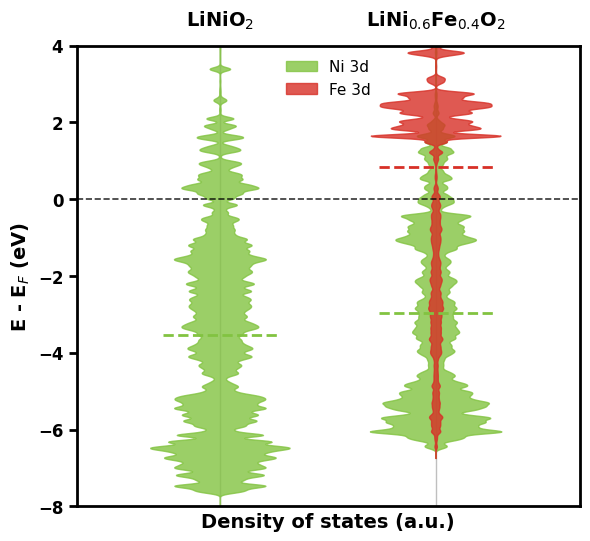

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

def plot_unified_violin_dos(data_list, titles, smoothing_sigma=3):
    fig, ax = plt.subplots(figsize=(6, 5.5))
    
    # 시스템 간 간격 설정 (x축 위치)
    offsets = [0, 1.5] 
    colors = {'Ni': '#82C341', 'Fe': '#D73027'} 
    
    for idx, data in enumerate(data_list):
        offset = offsets[idx]
        energies_rel = data['energies'] - data['efermi']
        spec_data = data['species_dict']
        
        # 시스템 중앙 수직선
        ax.axvline(offset, color='gray', lw=1, alpha=0.5, zorder=1)
        
        # Ni 먼저, Fe 나중 (겹침 방지)
        sorted_specs = sorted(spec_data.keys(), key=lambda x: x == 'Fe') 

        for spec in sorted_specs:
            content = spec_data[spec]
            dos = content['total_dos']
            dbc_rel = content['dbc'] - data['efermi']
            color = colors.get(spec, 'black')
            
            # DOS 정규화 (너비 조절)
            norm_dos = (dos / np.max(dos)) * 1.8
            smoothed_dos = gaussian_filter(norm_dos, sigma=smoothing_sigma)
            
            # 대칭형 채우기: offset 기준 좌우로 펼침
            ax.fill_betweenx(energies_rel, offset - smoothed_dos, offset + smoothed_dos, 
                             color=color, alpha=0.8, label=f'{spec} 3d' if idx == 1 else "", zorder=2)
            
            # --- [DBC 표시] ---
            # 바이올린 내부를 가로지르는 짧은 수평선
            ax.hlines(dbc_rel, offset - 0.4, offset + 0.4, color=color, ls='--', lw=2, zorder=5)
            
            # DBC 수치 텍스트 (바이올린 바로 옆 내부 공간에 배치)
            # ax.text(offset + 0.5, dbc_rel+0.5, f'$\epsilon_d$= {dbc_rel:.2f} eV', 
            #         color=color, fontsize=10, fontweight='bold', va='center')

        # 시스템 제목 (그래프 상단)
        ax.text(offset, 4.5, titles[idx], fontsize=14, fontweight='bold', ha='center')

    # Fermi level (0 eV) 가로 실선
    ax.axhline(0, color='black', ls='--', lw=1.2, alpha=0.8, zorder=6)
    #ax.text(offsets[0] - 1.2, 0.5, '$E_F$', va='center', fontweight='bold', color='gray')
    #ax.set_box_aspect(1)
    # 스타일링
    ax.set_ylabel('E - E$_F$ (eV)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Density of states (a.u.)', fontsize=14, fontweight='bold')
    
    # x축 눈금 및 범위 설정
    ax.set_xticks([]) # x축 수치 제거 (a.u.)
    ax.set_xlim(offsets[0] - 1., offsets[-1] + 1.)
    ax.set_ylim(-8, 4)
    ax.tick_params(axis='y', labelsize=12, width=2.0, length=6)
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
    
    # 테두리 설정
    for spine in ax.spines.values():
        spine.set_linewidth(2.0)
    
    # 범례 (중복 제거)
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), frameon=False, loc='upper center', fontsize=11)
    
    plt.tight_layout()
    plt.show()

# --- 실행부 ---
data_lno = get_species_specific_data_spin(v_lno)
data_lnfo = get_species_specific_data_spin(v_lnfo)

titles = ["LiNiO$_2$", "LiNi$_{0.6}$Fe$_{0.4}$O$_2$"]
plot_unified_violin_dos([data_lno, data_lnfo], titles, smoothing_sigma=3)

In [8]:
def calculate_integrated_dbc(data):
    spec_data = data['species_dict']
    energies = data['energies']
    efermi = data['efermi']
    
    # 모든 원소의 DOS 합산
    total_d_dos = np.zeros_like(energies)
    for spec in spec_data:
        total_d_dos += spec_data[spec]['total_dos']
    
    # 통합 DBC 적분 계산
    num = np.trapezoid(energies * total_d_dos, x=energies)
    den = np.trapezoid(total_d_dos, x=energies)
    
    integrated_dbc = num / den
    return integrated_dbc - efermi # Fermi level 기준으로 반환

# 확인
total_dbc_lnfo = calculate_integrated_dbc(data_lnfo)
print(f"LNFO Integrated d-band center: {total_dbc_lnfo:.2f} eV")

LNFO Integrated d-band center: -1.80 eV


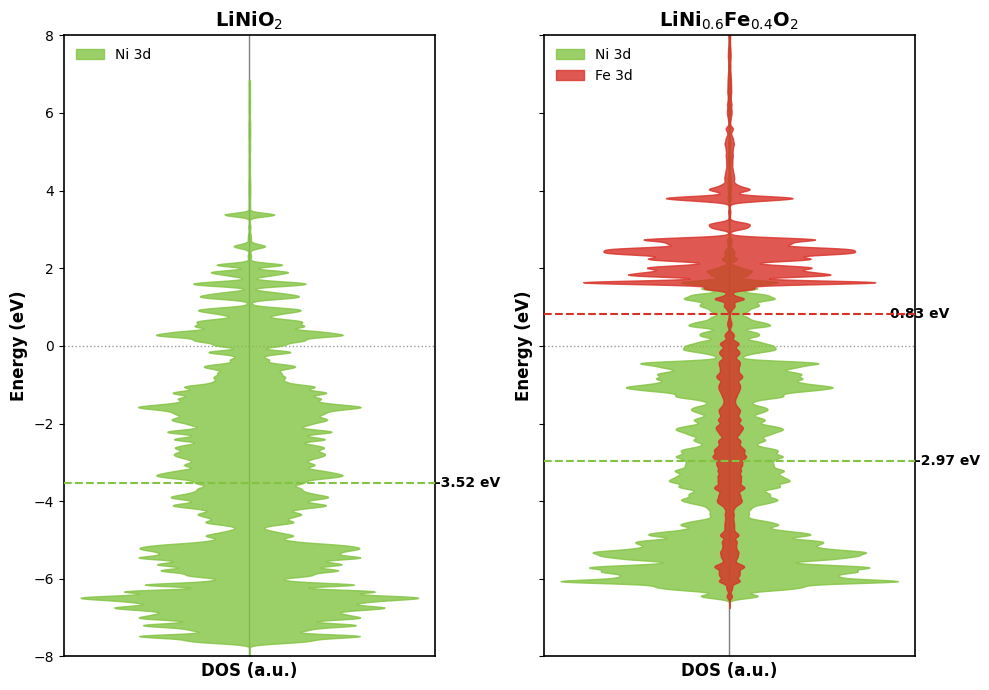

In [9]:
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

def plot_violin_dos(ax, data, title, smoothing_sigma=3):
    energies_rel = data['energies'] - data['efermi']
    spec_data = data['species_dict']
    
    # 이미지와 유사한 색상 설정 (Ni: Green계열, Fe: Red계열)
    colors = {'Ni': '#82C341', 'Fe': '#D73027'} 
    
    # 베이스 라인 (중앙 수직선)
    ax.axvline(0, color='black', lw=1, alpha=0.5)

    # 원소별로 대칭형 채우기 (보통 더 넓은 범위를 가진 원소를 먼저 그립니다)
    # 여기서는 Ni을 배경으로, Fe를 안쪽 핵심으로 그리는 순서로 가정 (이미지 스타일)
    sorted_specs = sorted(spec_data.keys(), key=lambda x: x == 'Fe') # Ni 먼저, Fe 나중

    for spec in sorted_specs:
        content = spec_data[spec]
        # 시각화를 위해 업/다운 합산된 total_dos를 대칭으로 사용
        # (만약 스핀 비대칭을 보여주고 싶다면 up과 -down을 각각 좌우에 배치 가능)
        dos = content['total_dos']
        dbc_rel = content['dbc'] - data['efermi']
        color = colors.get(spec, 'black')
        
        smoothed_dos = gaussian_filter(dos, sigma=smoothing_sigma)
        
        # 대칭형 채우기: -smoothed_dos 부터 +smoothed_dos 까지
        ax.fill_betweenx(energies_rel, -smoothed_dos, smoothed_dos, 
                         color=color, alpha=0.8, label=f'{spec} 3d', zorder=2)
        
        # d-band center 수평 점선
        ax.axhline(dbc_rel, color=color, ls='--', lw=1.5, zorder=5)
        
        # dbc 수치 텍스트
        ax.text(np.max(smoothed_dos)*1.1, dbc_rel, f'{dbc_rel:.2f} eV', 
                color='black', fontsize=10, va='center', fontweight='bold')

    # Fermi level (0 eV) 가로 실선
    ax.axhline(0, color='gray', ls=':', lw=1, alpha=0.8, zorder=1)

    # 스타일링
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Energy (eV)', fontsize=12, fontweight='bold')
    ax.set_xlabel('DOS (a.u.)', fontsize=12, fontweight='bold')
    
    # x축 눈금 제거 (Violin plot 특성상 수치는 생략하고 중앙 대칭 강조)
    ax.set_xticks([])
    ax.set_ylim(-8, 8) # 에너지 범위 설정
    
    # 범례
    ax.legend(frameon=False, loc='upper left', fontsize=10)
    
    # 테두리 정리
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)

data_lno = get_species_specific_data_spin(v_lno)
data_lnfo = get_species_specific_data_spin(v_lnfo)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 7), sharey=True)

# LNO 그리기
plot_violin_dos(ax1, data_lno, "LiNiO$_2$", smoothing_sigma=3)

# LNFO 그리기
plot_violin_dos(ax2, data_lnfo, "LiNi$_{0.6}$Fe$_{0.4}$O$_2$", smoothing_sigma=3)

plt.tight_layout()
plt.show()

In [10]:
# def plot_overlapping_dos(ax, data, title, smoothing_sigma = 3):
#     energies_rel = data['energies'] - data['efermi']
#     spec_data = data['species_dict']
    
#     # 원소별 색상 지정
#     colors = {'Ni': "#1ebd5e", 'Fe': '#ff7f0e'} 
    
#     for spec, content in spec_data.items():
#         dos = content['dos']
#         dbc = content['dbc'] - data['efermi'] # Ef 기준으로 보정
#         color = colors.get(spec, 'black')
        
#         # 1. 부드럽게 만들기
#         smoothed_dos = gaussian_filter(dos, sigma=smoothing_sigma)
        
#         # 2. 겹쳐 그리기 (alpha=0.4 로 투명도 설정)
#         ax.fill_betweenx(energies_rel, 0, smoothed_dos, 
#                          where=(energies_rel <= 0), 
#                          color=color, alpha=0.4, label=spec)   

#         # 3. 외곽선은 선명하게
#         ax.plot(smoothed_dos, energies_rel, color=color, lw=1.5, alpha=0.8)
        
#         # 4. 각 원소의 d-band center 선 (DBC)
#         ax.axhline(dbc, color=color, ls='-.', lw=2)
        
#         # 5. 수치 텍스트 표시
#         # (원소별로 텍스트가 겹치지 않게 y 위치를 살짝 조정하는 로직을 넣으면 더 좋습니다)

#     # Fermi level (0 eV)
#     ax.axhline(0, color='black', ls=':', lw=1.5)
    
#     # 스타일링
#     ax.set_title(title, fontsize=15, fontweight='bold')
#     ax.set_ylim(-8, 4)
#     ax.set_xlim(left=0)
#     ax.legend(frameon=False)
#     ax.set_xlabel('DOS (a.u.)', fontweight='bold')

